## EDA по данным риелторской компании

В файле clients.csv предоставлена информация о клиентах риелторской компании США за один месяц. Вам необходимо как специалисту по Data Science сделать следующее:

- Провести разведочный анализ данных, посмотреть на датасет, есть ли пропуски - посмотреть на зависимости признаков
- Используя данные о выборке, постройте типичный портрет целевого клиента компании (пол, возраст, какой тип квартиры он приобретает, какова площадь в кв. м , каков средний чек, цель покупки, источник лида (погуглите что такое лид в маркетинге, за это отвечает колонка Source).

Таким образом после вашего анализа, я хочу увидеть описание нашего целевого клиента с соответствующими визуализациями. Ожидаю увидеть как минимум 5 графиков с комментариями. Отнеситесь к заданию достойно, представьте, что от Вашего отчета зависит принятие важного решения.

---

**Баллы могут быть снижены** за качество кода - старайтесь чтобы код был максимально лаконичным. Названия переменных (если они используются) должны отражать максимальную ее сущность.

**Комментарии по сдаче практического задания**:
1. Залить в репу на github в папку module_2/descriptive_stats
2. Ссылку на репо отправлять мне на почту alexadevv@gmail.com не позднее дедлайна.
3. Тема письма: Домашнее задание по модулю 2 <Фамилия Имя>
4. После дедлайна, неотправленные на почту задания, оцениваются максимум в 7 баллов.

In [79]:
import pandas as pd
import numpy as np                
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from datetime import datetime

In [80]:
data = pd.read_csv('clients.csv')
data.columns = data.columns.str.replace(' ', '_') # не селектятся наши поля у которых есть пробелы, как вариант можем заменить наши пробелы  на "_"
data.head(10)

,ID,Building,Year_of_sale,Month_of_sale,Type_of_property,Property_number,Area_(ft.),Price,Status,Customer_ID,...,Y,M,D,Gender,Country,State,Purpose,Deal_satisfaction,Mortgage,Source
0,1030,1,2005,11,Apartment,30,743.09,"$ 246,172.68",Sold,C0028,...,1986.0,6.0,21.0,F,USA,California,Home,5,No,Website
1,1029,1,2005,10,Apartment,29,756.21,"$ 246,331.90",Sold,C0027,...,1983.0,2.0,24.0,F,USA,California,Home,5,No,Website
2,2002,2,2007,7,Apartment,2,587.28,"$ 209,280.91",Sold,C0112,...,1985.0,12.0,27.0,M,USA,California,Home,1,Yes,Client
3,2031,2,2007,12,Apartment,31,1604.75,"$ 452,667.01",Sold,C0160,...,1985.0,12.0,27.0,M,USA,California,Investment,3,Yes,Website
4,1049,1,2004,11,Apartment,49,1375.45,"$ 467,083.31",Sold,C0014,...,1979.0,5.0,15.0,F,USA,California,Home,4,No,Agency
5,3011,3,2007,9,Apartment,11,675.19,"$ 203,491.85",Sold,C0125,...,1981.0,12.0,26.0,F,USA,Virginia,Investment,5,No,Client
6,3026,3,2007,9,Apartment,26,670.89,"$ 212,520.83",Sold,C0125,...,1981.0,12.0,26.0,F,USA,Virginia,Investment,5,No,Agency
7,3023,3,2008,1,Apartment,23,720.81,"$ 198,591.85",Sold,C0166,...,1982.0,5.0,27.0,M,USA,California,Home,5,No,Client
8,1031,1,2006,6,Apartment,31,782.25,"$ 265,467.68",Sold,C0034,...,1979.0,6.0,27.0,M,USA,Arizona,Home,2,Yes,Website
9,4023,4,2006,3,Apartment,23,794.52,"$ 235,633.26",Sold,C0170,...,1979.0,12.0,3.0,F,USA,Virginia,Investment,3,Yes,Agency


In [81]:
data.describe() # забавно, что люди в возрасте 19 лет способны купить дом стоимостью 246172.68$, Mortgage = No 

,ID,Building,Year_of_sale,Month_of_sale,Property_number,Area_(ft.),Age_at_time_of_purchase,Y,M,D,Deal_satisfaction
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,178.000000,178.000000,178.000000,178.000000,195.000000
mean,2591.425641,2.564103,2006.333333,7.271795,27.328205,899.867128,46.151685,1960.325843,6.752809,15.449438,3.605128
std,1244.617996,1.243434,1.072941,3.378674,14.830832,261.489550,12.841692,12.835575,3.450312,8.457285,1.363355
min,1002.000000,1.000000,2004.000000,1.000000,1.000000,410.710000,19.000000,1931.000000,1.000000,1.000000,1.000000
25%,2003.500000,2.000000,2006.000000,4.000000,15.000000,739.860000,37.000000,1950.250000,4.000000,8.000000,3.000000
50%,2054.000000,2.000000,2007.000000,8.000000,27.000000,785.480000,45.000000,1962.000000,6.000000,15.000000,4.000000
75%,3048.500000,3.000000,2007.000000,10.000000,39.000000,1075.460000,55.000000,1969.750000,9.750000,23.750000,5.000000
max,5051.000000,5.000000,2010.000000,12.000000,59.000000,1942.500000,76.000000,1986.000000,15.000000,31.000000,5.000000


In [82]:
data['Price'] = data['Price'].str.replace(r'\$', '', regex=True) # проблемотично работать с ценой в типе данных object поэтому переводим в float при этом удаляем лишние символы
data['Price'] = data['Price'].str.replace(',', '', regex=True)
data['Price'].dtype
data.Price = data.Price.astype(float)
data['Price'].dtype

dtype('float64')

In [100]:
data.shape

(195, 25)

In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       195 non-null    int64  
 1   Building                 195 non-null    int64  
 2   Year_of_sale             195 non-null    int64  
 3   Month_of_sale            195 non-null    int64  
 4   Type_of_property         195 non-null    object 
 5   Property_number          195 non-null    int64  
 6   Area_(ft.)               195 non-null    float64
 7   Price                    195 non-null    float64
 8   Status                   195 non-null    object 
 9   Customer_ID              195 non-null    object 
 10  Entity                   195 non-null    object 
 11  Name                     195 non-null    object 
 12  Surname                  195 non-null    object 
 13  Age_at_time_of_purchase  178 non-null    float64
 14  Age_Interval_            1

In [84]:
data.isnull().sum() # как мы видим у нас есть пустоты по некоторым фичам, размерность нашего dataset 195 на 25 простое удаление пустых строк 
                    # может повлиять на репрезентативность => будем заполнять используя SimpleImputer со стратегией = mean

ID                          0
Building                    0
Year_of_sale                0
Month_of_sale               0
Type_of_property            0
Property_number             0
Area_(ft.)                  0
Price                       0
Status                      0
Customer_ID                 0
Entity                      0
Name                        0
Surname                     0
Age_at_time_of_purchase    17
Age_Interval_              17
Y                          17
M                          17
D                          17
Gender                     17
Country                     0
State                      14
Purpose                     0
Deal_satisfaction           0
Mortgage                    0
Source                      0
dtype: int64

In [90]:
datacop = data.copy()
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    imputer = SimpleImputer(strategy='mean')
    datacop[numeric_cols] = imputer.fit_transform(data[numeric_cols])

In [101]:
categorical_cols = ['Gender', 'Age_Interval_', 'State'] # у нас имеются еще и категориальные данные с пустотами их заполняем самыми часто повторяющимися значениями
categorical_imputer = SimpleImputer(strategy='most_frequent')
datacop[categorical_cols] = categorical_imputer.fit_transform(datacop[categorical_cols])

C:\Users\huawei\AppData\Local\Temp\ipykernel_3576\3091124513.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(datacop.corr(), annot=True);


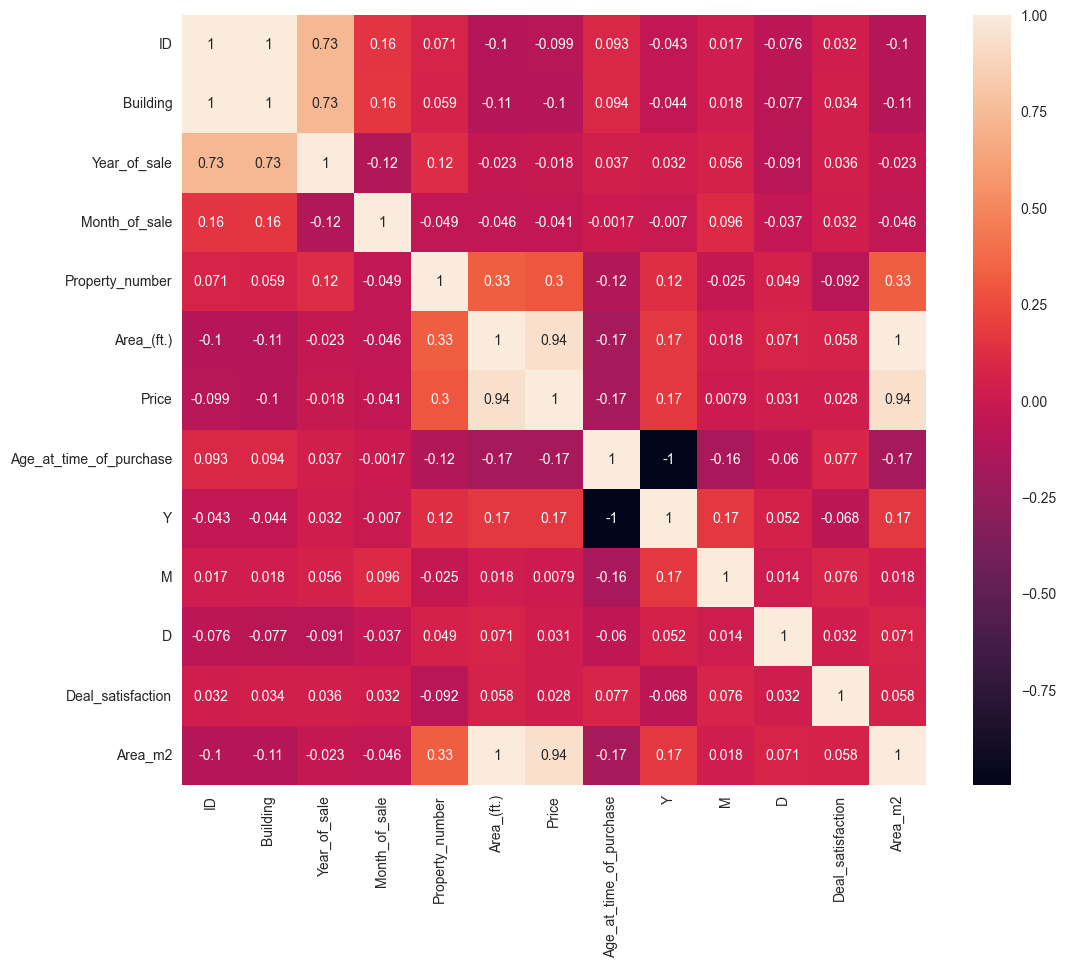

In [147]:
plt.figure(figsize=(12, 10))
sns.heatmap(datacop.corr(), annot=True);
plt.show()
# посмотрим на наши корреляции в hitmap, заметим, что существует сильная корреляция между ценой и Площадью в футах/кв.М., что достаточно логично

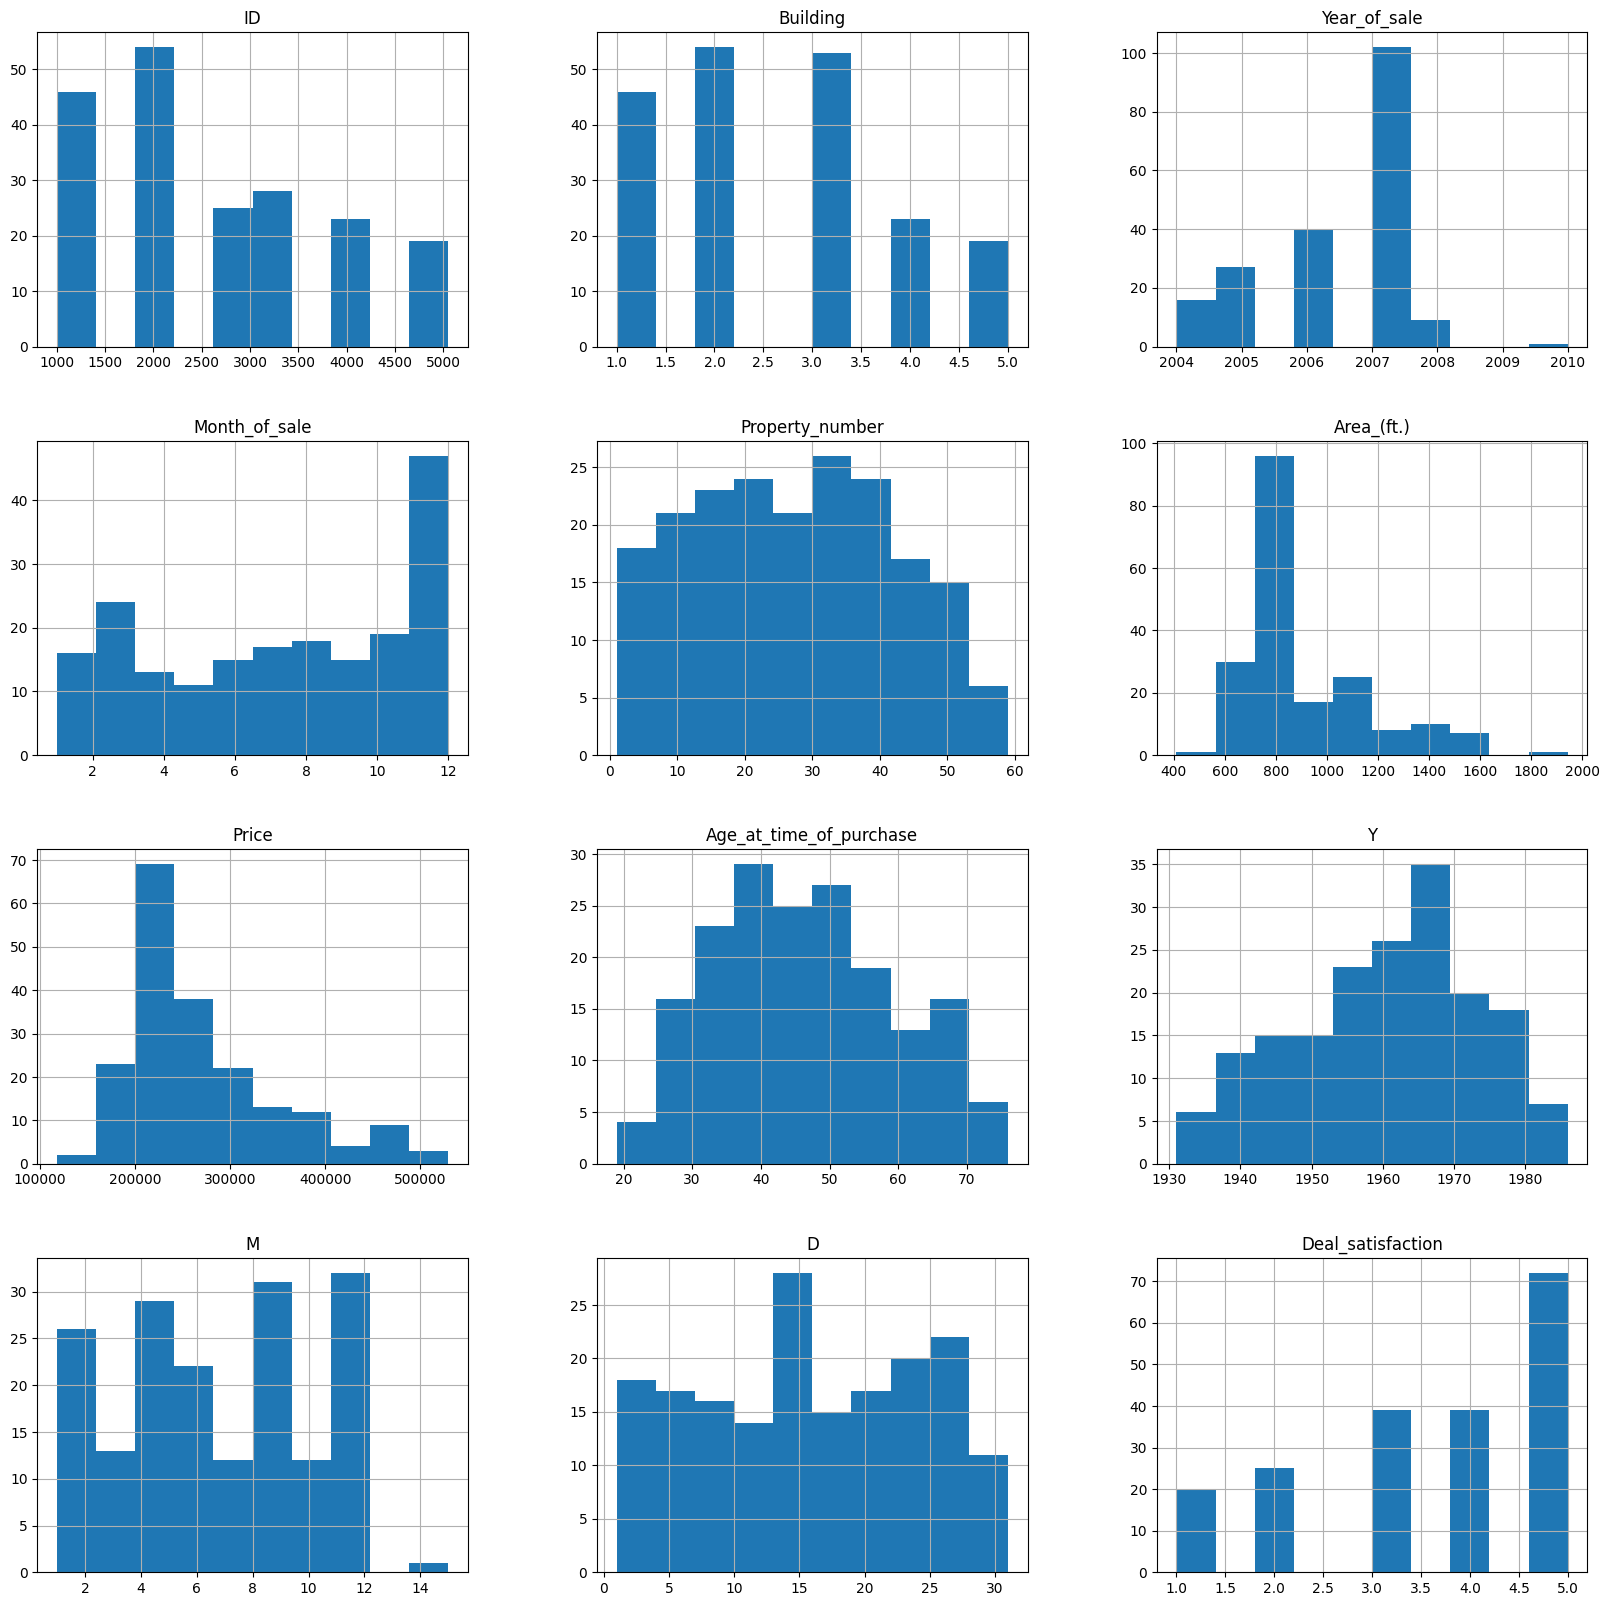

In [102]:
data.hist(figsize = (20,20)); #можем заметить что в фиче "М" у нас есть выброс - 15 месяц
plt.show() 

In [132]:
datacop = datacop[datacop['M'] != 15] # будем работать только месцами 1-12 выброс не будем учитывать теоретичиески это может быть март но инфы у нас нет, одна стркоа скорее всего не повлияет на результат

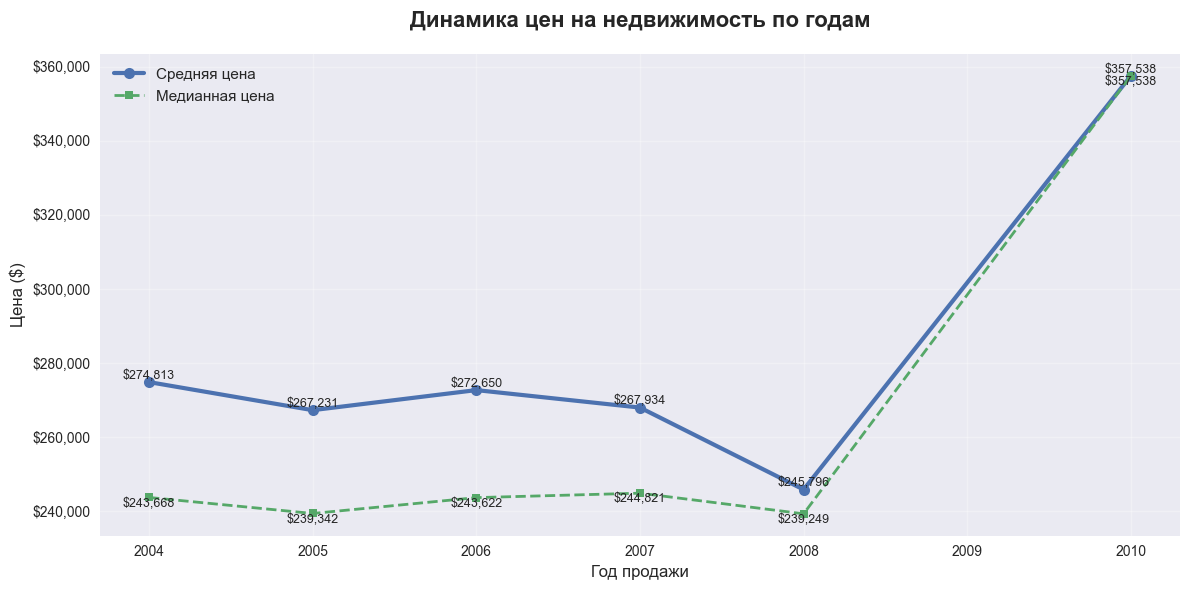

In [145]:
# посмотрим на график изменения цен за каждый год, можем заметить, что был сильный обвал цен в 2008 году => мы имеем скачек продаж
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))
yearly_prices = datacop.groupby('Year_of_sale')['Price'].agg(['mean', 'median', 'std', 'count']).reset_index()
plt.plot(yearly_prices['Year_of_sale'], yearly_prices['mean'], 
         marker='o', linewidth=3, markersize=8, label='Средняя цена')
plt.plot(yearly_prices['Year_of_sale'], yearly_prices['median'], 
         marker='s', linewidth=2, markersize=6, linestyle='--', label='Медианная цена')
plt.title('Динамика цен на недвижимость по годам', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Год продажи', fontsize=12)
plt.ylabel('Цена ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
for x, y_mean, y_median in zip(yearly_prices['Year_of_sale'], 
                               yearly_prices['mean'], 
                               yearly_prices['median']):
    plt.text(x, y_mean, f'${y_mean:,.0f}', ha='center', va='bottom', fontsize=9)
    plt.text(x, y_median, f'${y_median:,.0f}', ha='center', va='top', fontsize=9)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

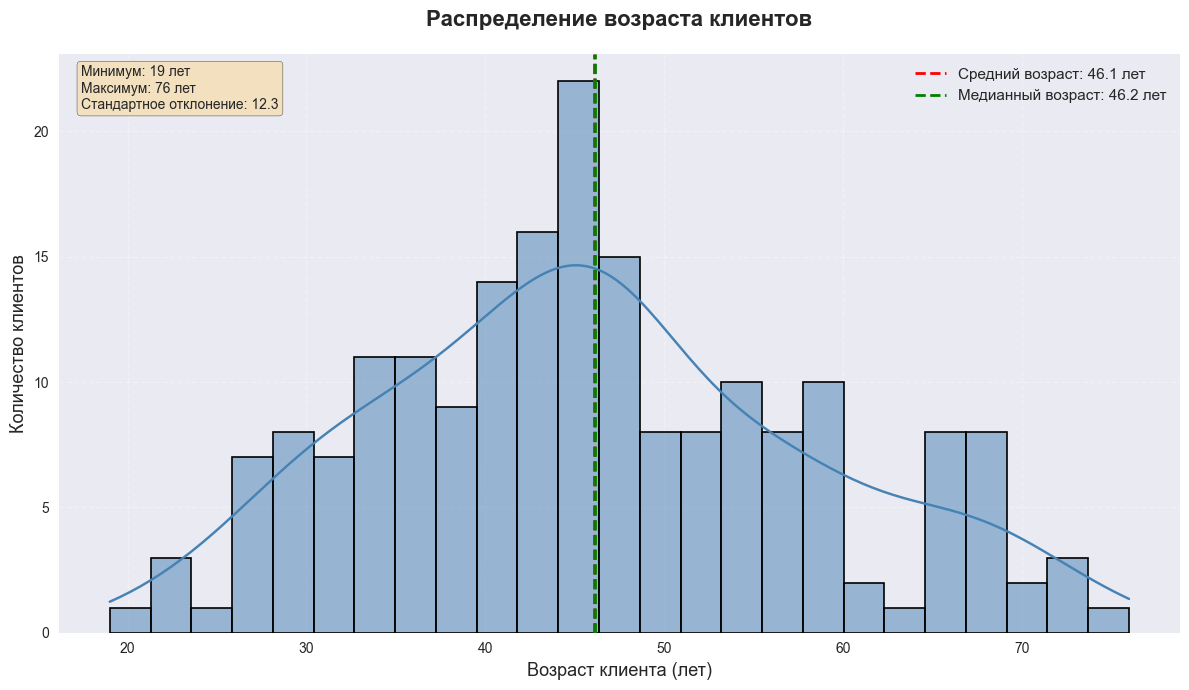

In [167]:
plt.figure(figsize=(12, 7)) # Нарисуем график распределения возраста клиентов
sns.histplot(data=datacop, x='Age_at_time_of_purchase', bins=25, 
             kde=True, color='steelblue', edgecolor='black', linewidth=1.2)
plt.title('Распределение возраста клиентов', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Возраст клиента (лет)', fontsize=13)
plt.ylabel('Количество клиентов', fontsize=13)

mean_age = datacop['Age_at_time_of_purchase'].mean()
median_age = datacop['Age_at_time_of_purchase'].median()

plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Средний возраст: {mean_age:.1f} лет')
plt.axvline(median_age, color='green', linestyle='--', linewidth=2, label=f'Медианный возраст: {median_age:.1f} лет')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)

stats_text = f'Минимум: {datacop["Age_at_time_of_purchase"].min():.0f} лет\n' \
             f'Максимум: {datacop["Age_at_time_of_purchase"].max():.0f} лет\n' \
             f'Стандартное отклонение: {datacop["Age_at_time_of_purchase"].std():.1f}'

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

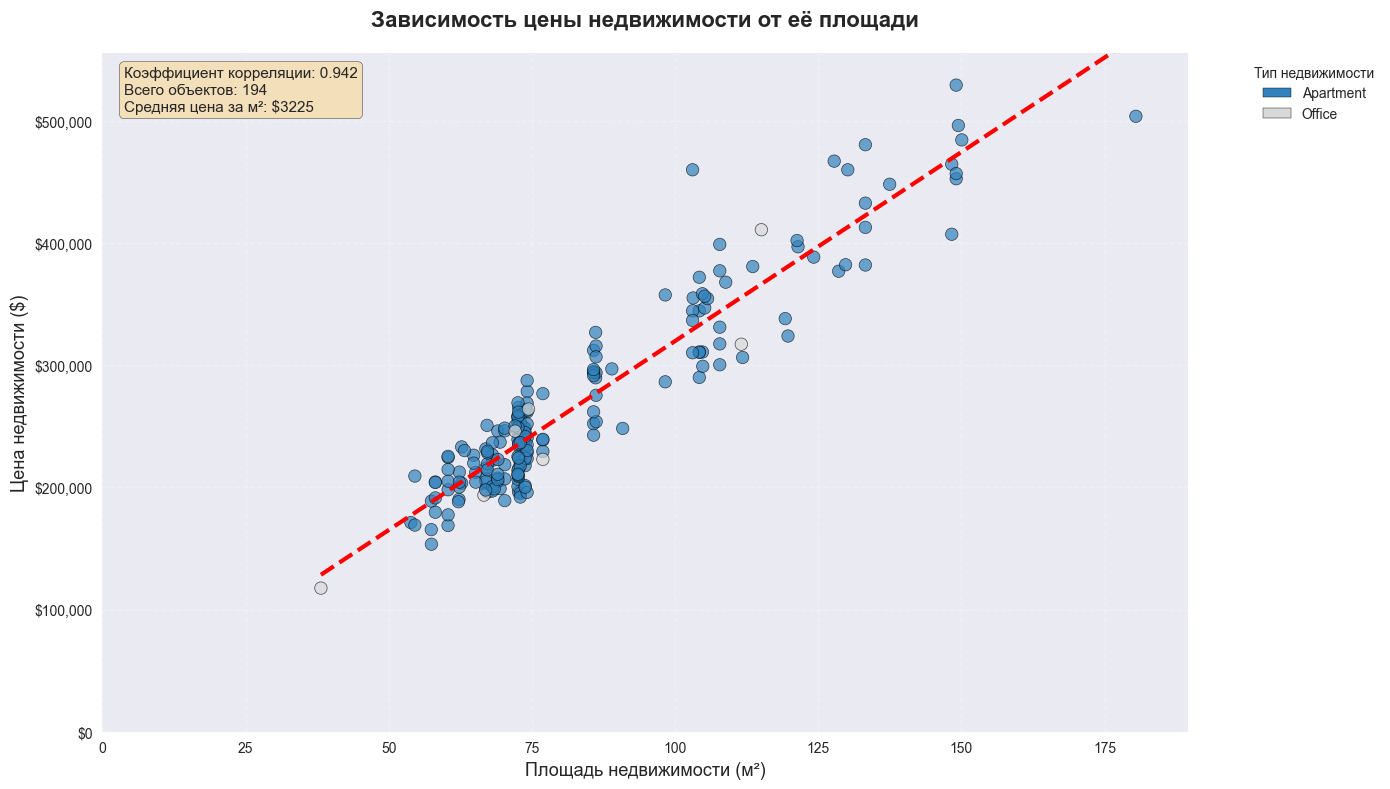

In [169]:
plt.figure(figsize=(14, 8))
scatter = plt.scatter(datacop['Area_m2'], datacop['Price'], # будем использовать Scatter plot
                     c=datacop['Type_of_property'].astype('category').cat.codes, 
                     cmap='tab20c', alpha=0.7, s=80, edgecolor='black', linewidth=0.5)
plt.title('Зависимость цены недвижимости от её площади', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Площадь недвижимости (м²)', fontsize=13)
plt.ylabel('Цена недвижимости ($)', fontsize=13)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}')) # здесь форматируем оси

z = np.polyfit(datacop['Area_m2'], datacop['Price'], 1) # Добавляем линию тренда (линейную регрессию)
p = np.poly1d(z)
plt.plot(np.sort(datacop['Area_m2']), p(np.sort(datacop['Area_m2'])),
         color='red', linewidth=3, linestyle='--', 
         label=f'Линия тренда: y = {z[0]:.0f}x + {z[1]:.0f}')
unique_types = datacop['Type_of_property'].unique()
colors = scatter.cmap(scatter.norm(np.arange(len(unique_types))))
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', 
                         label=unique_types[i]) for i in range(len(unique_types))]

plt.legend(handles=legend_elements, title='Тип недвижимости', 
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
correlation = datacop['Area_m2'].corr(datacop['Price'])
stats_text = f'Коэффициент корреляции: {correlation:.3f}\n' \
             f'Всего объектов: {len(datacop)}\n' \
             f'Средняя цена за м²: ${(datacop["Price"]/datacop["Area_m2"]).mean():.0f}'

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
plt.xlim(0, datacop['Area_m2'].max() * 1.05)
plt.ylim(0, datacop['Price'].max() * 1.05)
plt.tight_layout()
plt.show()

C:\Users\huawei\AppData\Local\Temp\ipykernel_3576\2232365154.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datacop, x='Age_Interval_', y='Price',


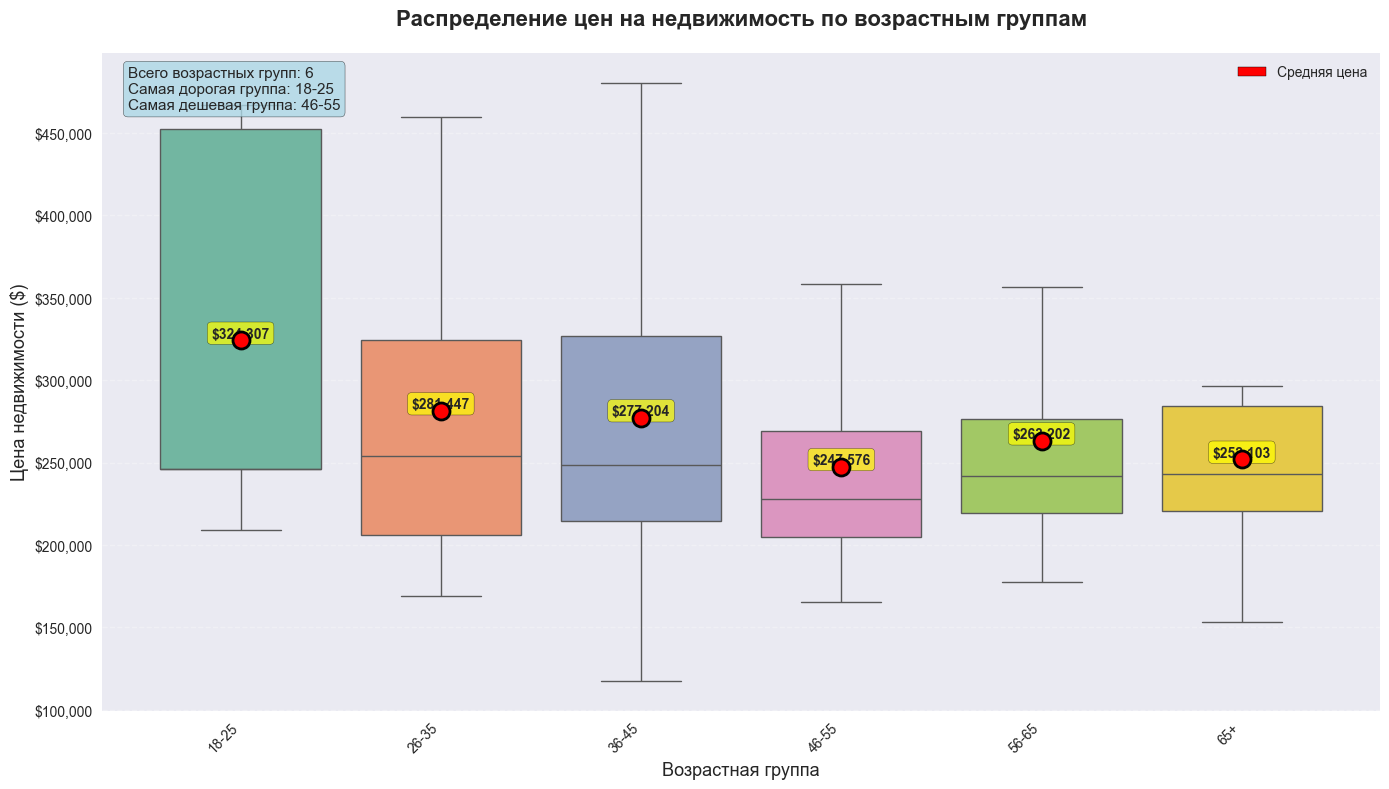

In [172]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=datacop, x='Age_Interval_', y='Price', 
            palette='Set2', showfliers=False)  # скрываем выбросы
plt.title('Распределение цен на недвижимость по возрастным группам', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Возрастная группа', fontsize=13)
plt.ylabel('Цена недвижимости ($)', fontsize=13)
plt.xticks(rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

age_groups = datacop['Age_Interval_'].unique()
for i, group in enumerate(age_groups):
    group_data = datacop[datacop['Age_Interval_'] == group]['Price']
    mean_price = group_data.mean()
    plt.scatter(i, mean_price, color='red', s=150, zorder=5, # оказывается можно разместить среднее значение на графике в виде точки
                edgecolor='black', linewidth=2, label='Среднее' if i == 0 else "")
    plt.text(i, mean_price, f'${mean_price:,.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
red_dot = Patch(facecolor='red', edgecolor='black', label='Средняя цена')
plt.legend(handles=[red_dot], loc='upper right')
stats_text = f"Всего возрастных групп: {len(age_groups)}\n" \
             f"Самая дорогая группа: {datacop.groupby('Age_Interval_')['Price'].mean().idxmax()}\n" \
             f"Самая дешевая группа: {datacop.groupby('Age_Interval_')['Price'].mean().idxmin()}"
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
plt.tight_layout()
plt.show()

In [174]:
# построим портрет целевого клиента
datacop['Area_m2'] = datacop['Area_(ft.)'] * 0.092903 # преобразуем в кв.м.

print("Портрет целевого клиента:")
male = datacop[datacop['Gender'] == 'M'].shape[0] / len(datacop) * 100
print(f"1. ГЕНДЕР:")
print(f"Мужчины: {male:.1f}%")
print(f"Женщины: {100-male:.1f}%")
mean_age = datacop['Age_at_time_of_purchase'].mean()
median_age = datacop['Age_at_time_of_purchase'].median()
age_mode = datacop['Age_Interval_'].mode()[0] if not datacop['Age_Interval_'].mode().empty else 'N/A'
print(f"\n2. ВОЗРАСТ:")
print(f"Средний возраст: {mean_age:.1f} лет")
print(f"Медианный возраст: {median_age:.1f} лет")
print(f"Самый частый возрастной интервал: {age_mode}")
top_properties = datacop['Type_of_property'].value_counts(normalize=True).head(3)
print(f"\n3. ТИП НЕДВИЖИМОСТИ:")
for i, (prop_type, perc) in enumerate(top_properties.items(), 1):
    print(f"{prop_type}: {perc*100:.1f}%")
mean_area = datacop['Area_m2'].mean()
median_area = datacop['Area_m2'].median()
print(f"\n4. ПЛОЩАДЬ:")
print(f"Средняя площадь: {mean_area:.1f} м²")
print(f"Типичная (медианная) площадь: {median_area:.1f} м²")
mean_price = datacop['Price'].mean()
median_price = datacop['Price'].median()
price_per_m2 = (datacop['Price'] / datacop['Area_m2']).mean()
print(f"\n5. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ:")
print(f"Средний чек: ${mean_price:,.0f}")
print(f"Медианная цена: ${median_price:,.0f}")
print(f"Средняя цена за м²: ${price_per_m2:.0f}")
mortgage_pct = datacop[datacop['Mortgage'] == 'Yes'].shape[0] / len(datacop) * 100
print(f"\n6. ИПОТЕКА:")
print(f"Клиентов с ипотекой: {mortgage_pct:.1f}%")
top_purposes = datacop['Purpose'].value_counts(normalize=True)
print(f"\n7. ЦЕЛЬ ПОКУПКИ:")
for i, (purpose, perc) in enumerate(top_purposes.items(), 1):
    print(f"{purpose}: {perc*100:.1f}%")
top_sources = datacop['Source'].value_counts(normalize=True)
print(f"\n8. ИСТОЧНИКИ ЛИДОВ:")
for i, (source, perc) in enumerate(top_sources.items(), 1):
    print(f"{source}: {perc*100:.1f}%")
satisfied_pct = datacop[datacop['Deal_satisfaction'] >= 3].shape[0] / len(datacop) * 100 # предположительно 3 - нижний порог удовлетворенности клинета
print(f"\n9. УДОВЛЕТВОРЕННОСТЬ:")
print(f"Довольных сделкой: {satisfied_pct:.1f}%")
top_countries = datacop['Country'].value_counts().head(5)
print(f"\n10. ТОП-5 СТРАН ПО КОЛИЧЕСТВУ ПОКУПОК:")
for country, count in top_countries.items():
    percentage = count/len(datacop)*100
    print(f"{country}: {count} покупок ({percentage:.1f}%)")

Портрет целевого клиента:
1. ГЕНДЕР:
Мужчины: 64.4%
Женщины: 35.6%

2. ВОЗРАСТ:
Средний возраст: 46.1 лет
Медианный возраст: 46.2 лет
Самый частый возрастной интервал: 36-45

3. ТИП НЕДВИЖИМОСТИ:
Apartment: 96.4%
Office: 3.6%

4. ПЛОЩАДЬ:
Средняя площадь: 83.5 м²
Типичная (медианная) площадь: 73.0 м²

5. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ:
Средний чек: $268,811
Медианная цена: $242,897
Средняя цена за м²: $3225

6. ИПОТЕКА:
Клиентов с ипотекой: 31.4%

7. ЦЕЛЬ ПОКУПКИ:
Home: 60.8%
Investment: 39.2%

8. ИСТОЧНИКИ ЛИДОВ:
Website: 60.8%
Agency: 30.4%
Client: 8.8%

9. УДОВЛЕТВОРЕННОСТЬ:
Довольных сделкой: 76.8%

10. ТОП-5 СТРАН ПО КОЛИЧЕСТВУ ПОКУПОК:
USA: 164 покупок (84.5%)
USA : 12 покупок (6.2%)
Canada: 7 покупок (3.6%)
Russia: 4 покупок (2.1%)
UK: 2 покупок (1.0%)
